# Bonificación Práctica

## Lectura de datos

In [81]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("darkgrid")

# Ruta a los archivos .csv 
ex_1 = "C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Bonificacion_1/train/ex_1.csv"
ex_9 = "C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Bonificacion_1/train/ex_9.csv"
ex_20 = "C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Bonificacion_1/train/ex_20.csv"
ex_21 = "C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Bonificacion_1/train/ex_21.csv"
ex_23 = "C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Bonificacion_1/train/ex_23.csv"
ex_24 = "C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Bonificacion_1/train/ex_24.csv"
ex_4 = "C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Bonificacion_1/test/ex_4.csv"
ex_22 = "C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Bonificacion_1/test/ex_22.csv"

# Lee los archivos .csv en DataFrames
train_1 = pd.read_csv(ex_1)
train_2 = pd.read_csv(ex_9)
train_3 = pd.read_csv(ex_20)
train_5 = pd.read_csv(ex_21)
train_4 = pd.read_csv(ex_23)
train_6 = pd.read_csv(ex_24)
test_1 = pd.read_csv(ex_4)
test_2 = pd.read_csv(ex_22)

train_1.index=train_1['time']
train_2.index=train_2['time']
train_3.index=train_3['time']
train_4.index=train_4['time']
train_5.index=train_5['time']
train_6.index=train_6['time']
test_1.index=test_1['time']
test_2.index=test_2['time']

train_1.drop('time', axis=1, inplace=True)
train_2.drop('time', axis=1, inplace=True)
train_3.drop('time', axis=1, inplace=True)
train_4.drop('time', axis=1, inplace=True)
train_5.drop('time', axis=1, inplace=True)
train_6.drop('time', axis=1, inplace=True)
test_1.drop('time', axis=1, inplace=True)
test_2.drop('time', axis=1, inplace=True)


## Gráficos y clasificación de las series

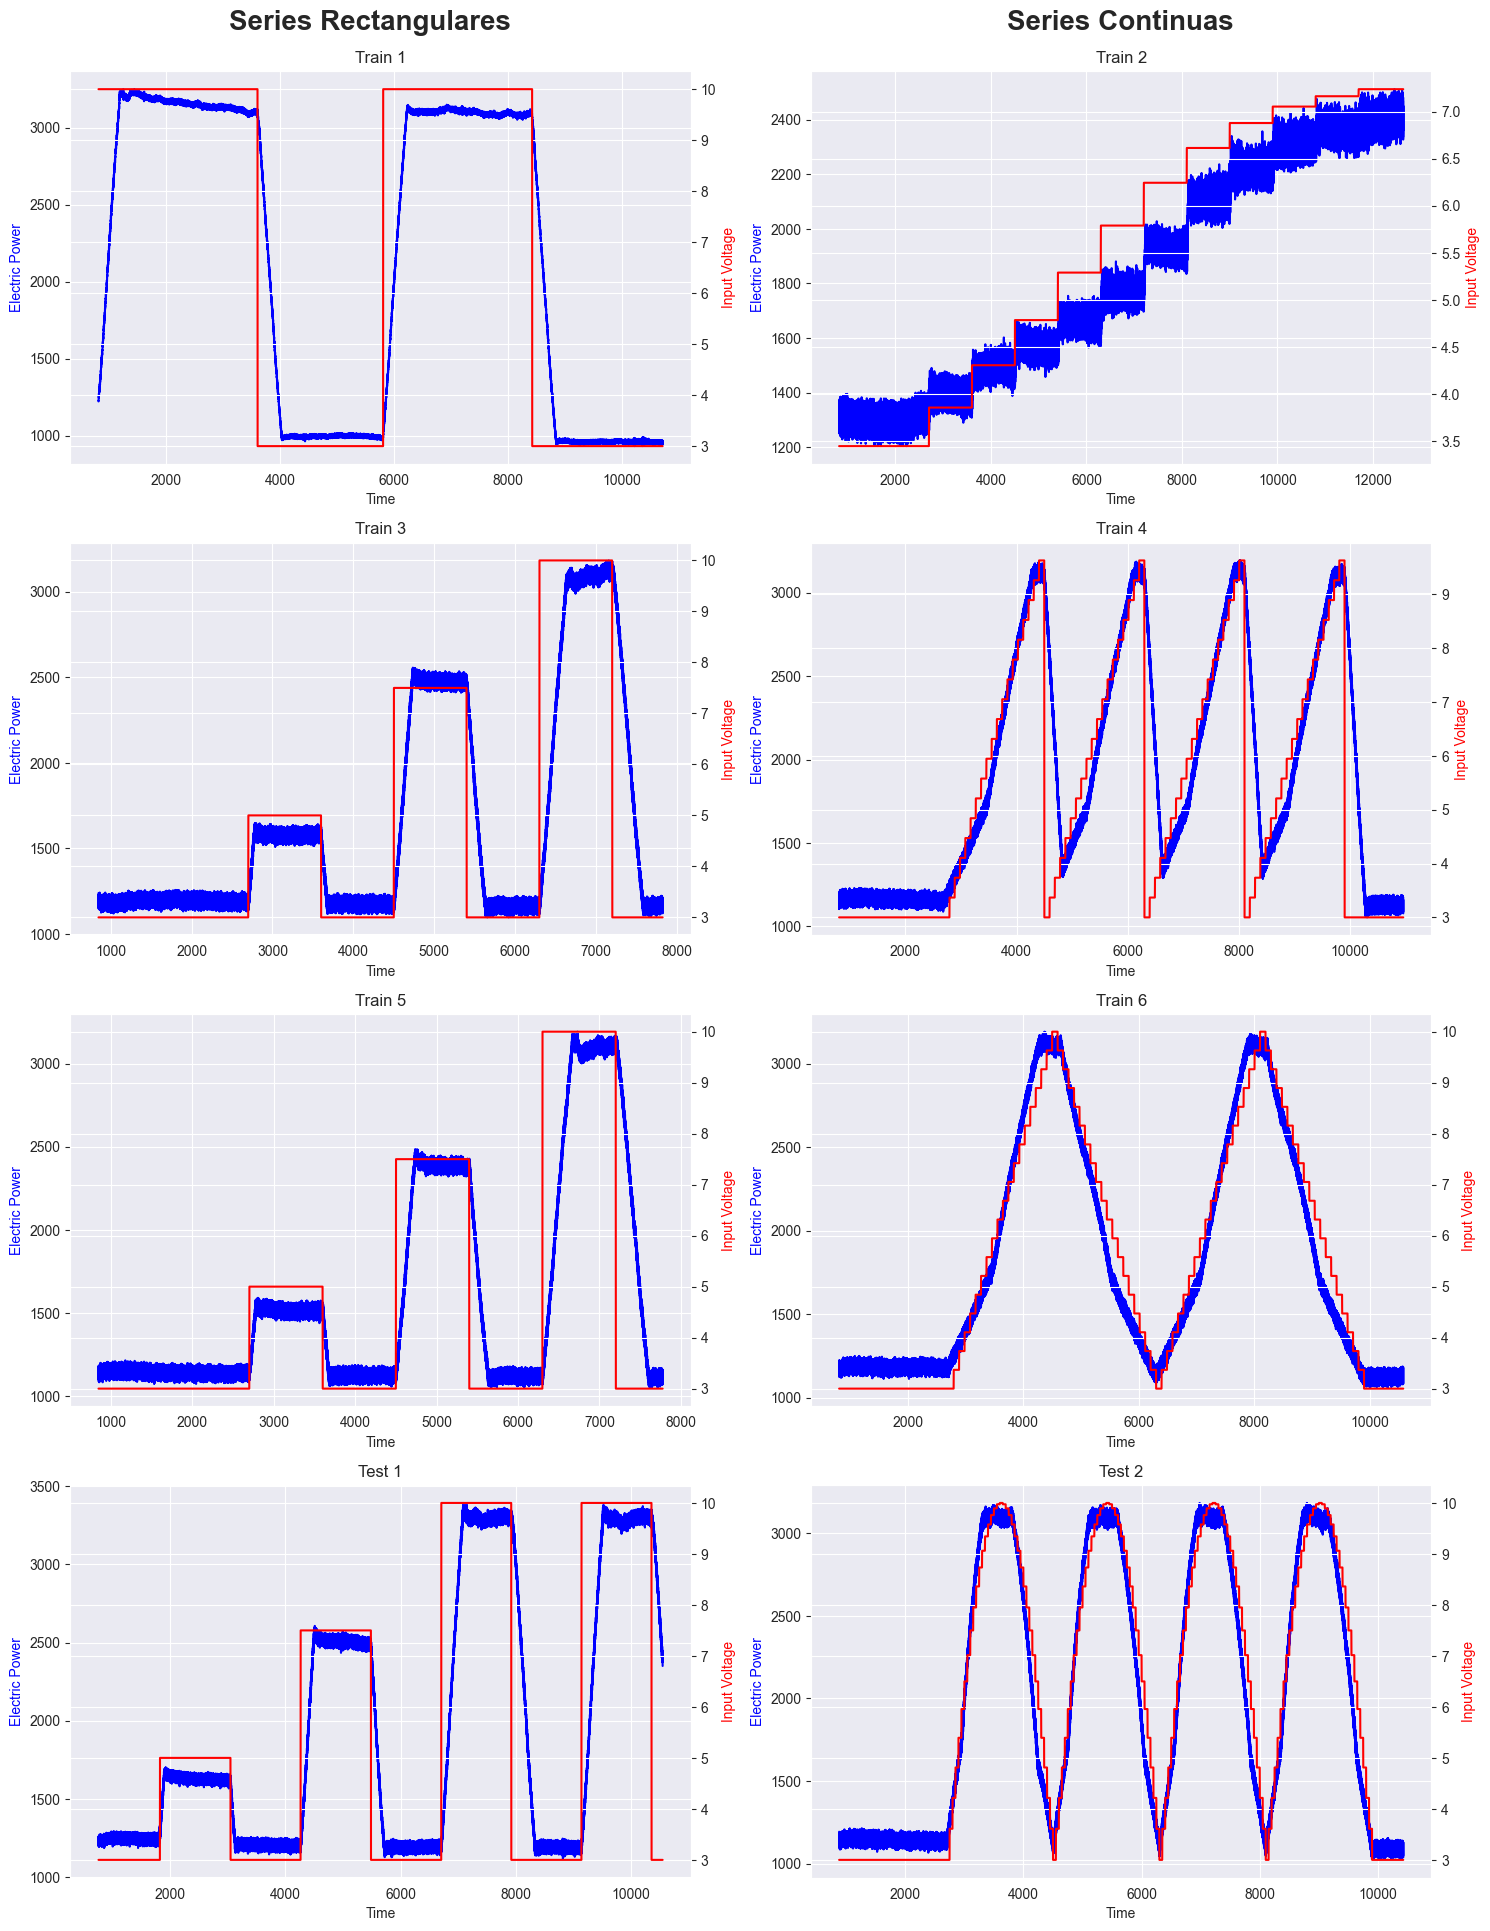

In [82]:
#Graficar datos organizados rectangulares y continuos

fig, axes = plt.subplots(4,2,figsize=(15,20))

for i, ax in enumerate(axes.flat):
    # Elegir el conjunto de datos correspondiente
    if i<6:
        train_data = [train_1, train_2, train_3 ,train_4, train_5, train_6][i] 
        ax.plot(train_data.index, train_data['el_power'], color='blue', label='Electric Power')
        ax.set_title(f'Train {i + 1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Electric Power', color='blue')
        ax2 = ax.twinx()
        ax2.plot(train_data.index, train_data['input_voltage'], color='red', label='Input Voltage')
        ax2.set_ylabel('Input Voltage', color='red')
    else:      
        test_data = [test_1,test_2][i-6]
        ax.plot(test_data.index, test_data['el_power'], color='blue', label='Electric Power')
        ax.set_title(f'Test {i -5}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Electric Power', color='blue')
        ax2 = ax.twinx()
        ax2.plot(test_data.index, test_data['input_voltage'], color='red', label='Input Voltage')
        ax2.set_ylabel('Input Voltage', color='red')
        
# Título para series de tiempo rectangulares
fig.text(0.25, 0.95, 'Series Rectangulares', fontsize=20, fontweight='bold', ha='center', va='bottom')

# Título para series de tiempo contínuas
fig.text(0.75, 0.95, 'Series Continuas', fontsize=20, fontweight='bold', ha='center', va='bottom')

# Ajustar el espaciado entre subgráficos
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Ajustar el espacio superior para el suptitle
plt.show()

## Propuesta de análisis

_"**Existen series de tiempo rectangulares y continuas** \
    _• Las **series de tiempo rectangulares** representan escenarios en los que la señal de control de entrada cambia instantáneamente, pero la potencia de salida sigue con un retraso visible. El modelado preciso de las transiciones y las fases estacionarias es crucial para la modelación de estas turbinas._\
    _• Las **series de tiempo continuas** representan escenarios donde la señal de control de entrada cambia gradualmente y no hay retrasos visibles en la potencia de salida. Para estas series de tiempo, aprender las transiciones es menos importante para modelar el comportamiento general."_\
<br>
Se propone utilizar dos modelos. El primero para modelar los datos de series de tiempo rectangulares, que permita ajustarse mejor a las transiciones y a las fases estacionarias. El segundo para modelar los datos de series de tiempo contínuas, que permita seguir mejor las tendencias de crecimiento gradual.

### Métrica de calificación

Se utilizará el $MAE$ como métrica de valoración del mejor ajuste.

## Series rectangulares

In [83]:
train_1_ts = pd.Series(data=train_1['el_power'].values, index=train_1.index).reset_index(drop=True)
train_3_ts = pd.Series(data=train_3['el_power'].values, index=train_3.index).reset_index(drop=True)
train_5_ts = pd.Series(data=train_5['el_power'].values, index=train_5.index).reset_index(drop=True)
train_ts_rect = [train_1_ts, train_3_ts, train_5_ts]


In [84]:
import numpy as np
import pandas as pd

# Define las funciones
def firstsmooth(y, lambda_, start=None):
    ytilde = y.copy()
    if start is None:
        start = y[0]
    ytilde[0] = lambda_ * y[0] + (1 - lambda_) * start
    for i in range(1, len(y)):
        ytilde[i] = lambda_ * y[i] + (1 - lambda_) * ytilde[i - 1]
    return ytilde


In [85]:
def measacc_fs(y, lambda_):
    out = firstsmooth(y, lambda_)
    T = len(y)
    yh = y.copy().values
    out = pd.concat([pd.Series([y[0]]), out[:-1]], ignore_index=True).values
    prederr = yh - out
    SSE = sum(prederr**2)
    MAPE = 100 * sum(abs(prederr / yh)) / T
    MAD = sum(abs(prederr)) / T
    MSD = sum(prederr**2) / T
    ret1 = pd.DataFrame({
        "SSE": [SSE],
        "MAPE": [MAPE],
        "MAD": [MAD],
        "MSD": [MSD]
    })
    ret1.reset_index(drop=True, inplace=True)    
    return ret1


### Selección $\lambda$

In [86]:
# Define el rango de lambda
lambda_vec = np.arange(0.1, 1.0, 0.05)

In [87]:
train_ts_rect[1]

0       1238.511285
1       1149.563728
2       1226.959165
3       1158.086961
4       1230.435294
           ...     
6490    1127.814015
6491    1214.491728
6492    1122.583290
6493    1207.778415
6494    1120.801636
Length: 6495, dtype: float64

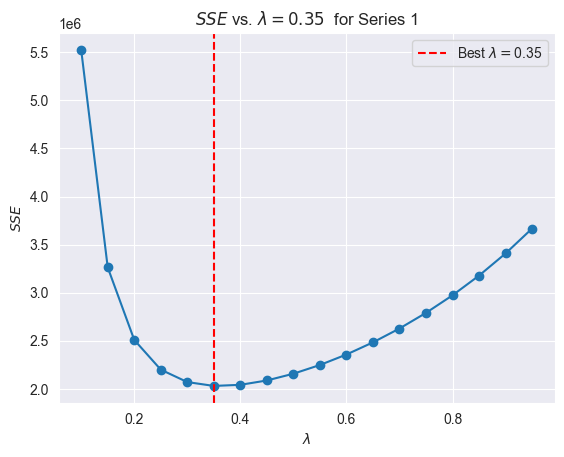

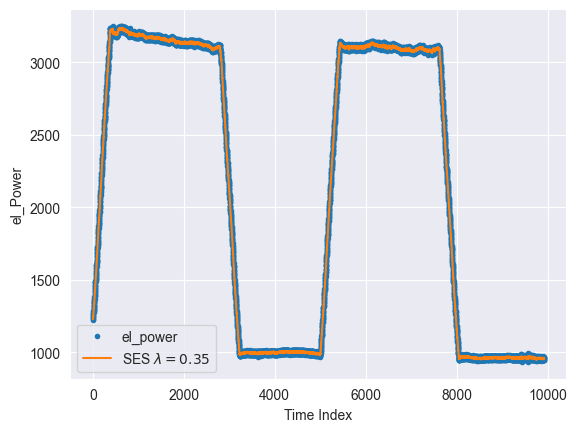

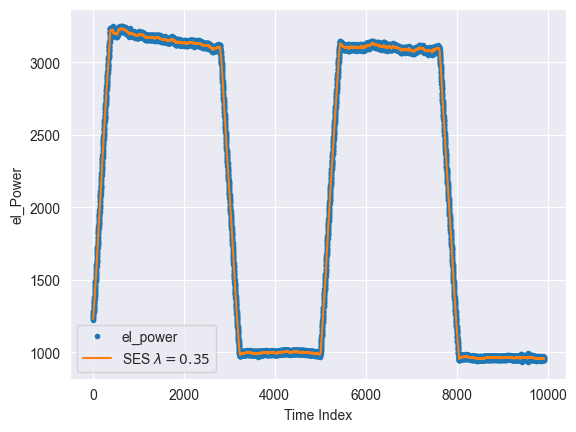

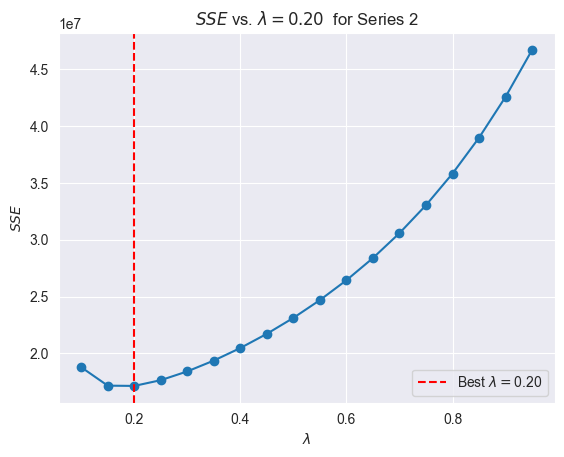

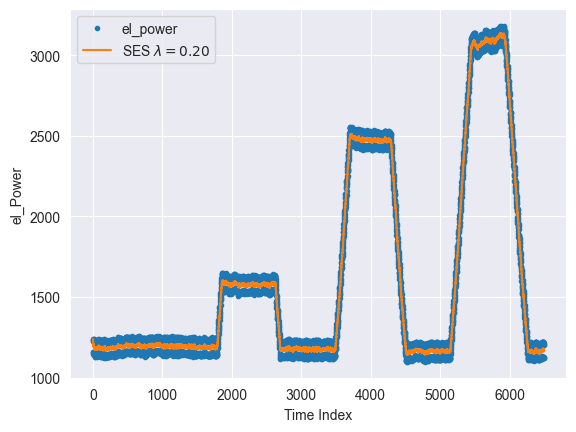

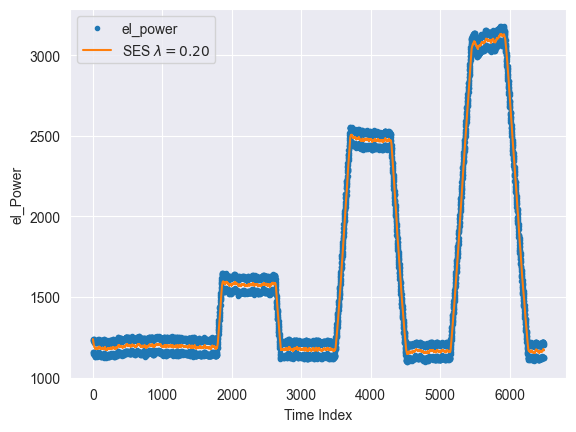

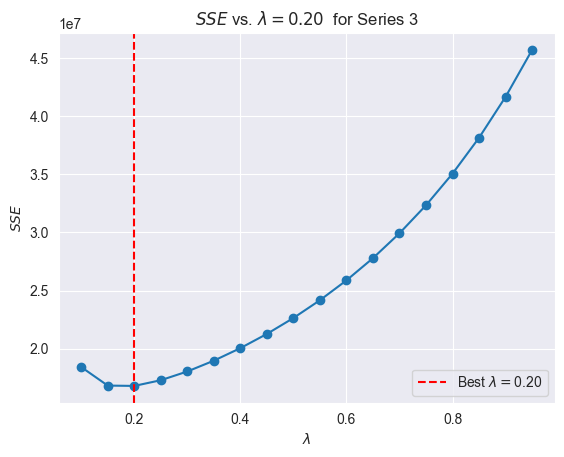

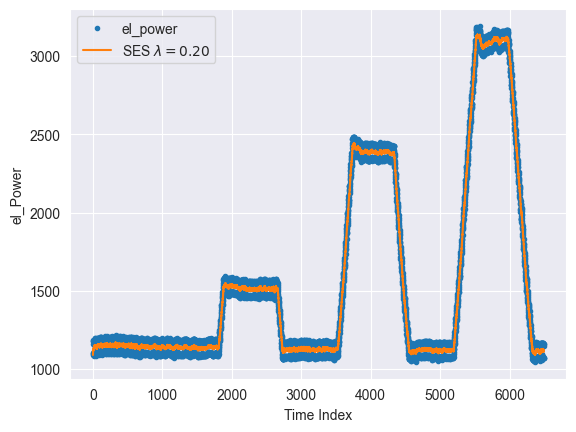

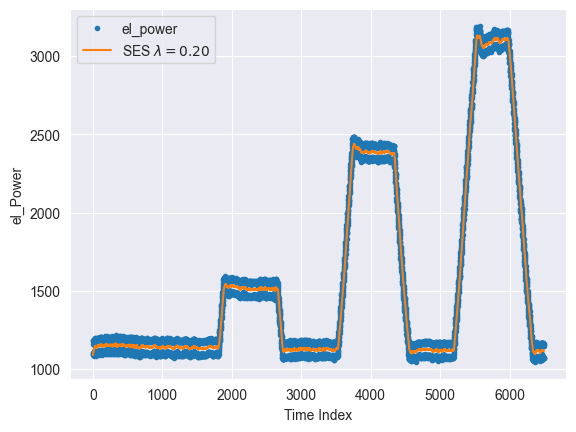

In [88]:
opt_lambda_vec=[]
for i, ts_rect in enumerate(train_ts_rect):
    # Define la función SSE
    def sse(sc):
        return measacc_fs(ts_rect, sc)['SSE'].values[0]

    # Inicializa sse_vec con el mismo tamaño que lambda_vec
    sse_vec = pd.Series(index=lambda_vec)

    # Calcula SSE para cada valor de lambda
    for lambda_ in lambda_vec:
        sse_vec.loc[lambda_] = sse(lambda_)

    # Filtra los valores NaN para evitar problemas
    sse_vec_filtered = sse_vec.dropna()

    # Asegúrate de que el mínimo existe antes de intentar graficar
    if not sse_vec_filtered.empty:
        opt_lambda = sse_vec_filtered.idxmin()
        opt_lambda_vec.append(opt_lambda)
        # Gráfico
        plt.plot(lambda_vec, sse_vec, marker='o', linestyle='-')
        plt.title(f"$SSE$ vs. $\lambda={opt_lambda:.2f}$  for Series {i+1}")
        plt.xlabel('$\lambda$')
        plt.ylabel('$SSE$')
        plt.axvline(x=opt_lambda, color='red', linestyle='--', label=f'Best $\lambda =${opt_lambda:.2f}')
        plt.legend()
        plt.show()
        
    smooth1 = firstsmooth(y=ts_rect, lambda_=opt_lambda)
    plt.plot(ts_rect, marker='o', linestyle='', markersize=3, label='el_power')
    plt.plot(smooth1, label=f'SES $\\lambda={opt_lambda:.2f}$')
    plt.xlabel('Time Index')
    plt.ylabel('el_Power')
    plt.legend()
    plt.show()
    
    smooth2 = firstsmooth(y=smooth1, lambda_=opt_lambda)
    plt.plot(ts_rect, marker='o', linestyle='', markersize=3, label='el_power')
    plt.plot(smooth2, label=f'SES $\\lambda={opt_lambda:.2f}$')
    plt.xlabel('Time Index')
    plt.ylabel('el_Power')
    plt.legend()
    plt.show()

In [89]:
opt_lambda_vec

[0.3500000000000001, 0.20000000000000004, 0.20000000000000004]

In [90]:
results = []
# Itera sobre los datos
for i, ts_rect in enumerate(train_ts_rect):
    for j, lambda_ in enumerate(opt_lambda_vec):
        # Calcula la métrica
        metrics = measacc_fs(y=ts_rect, lambda_=lambda_)
        
        # Guarda los resultados en la lista
        results.append({
            'Train': 2*i+1,
            'Lambda': lambda_,
            'SSE': metrics['SSE'].values[0],
            'MAPE': metrics['MAPE'].values[0],
            'MAD': metrics['MAD'].values[0],
            'MSD': metrics['MSD'].values[0]
        })

# Convierte la lista a un DataFrame
mx_result = pd.DataFrame(results)

# Muestra el DataFrame final
print(mx_result)

            

   Train  Lambda           SSE      MAPE        MAD          MSD
0      1    0.35  2.030363e+06  0.733870  12.738725   204.673736
1      1    0.20  2.508858e+06  0.774527  13.582499   252.909056
2      1    0.20  2.508858e+06  0.774527  13.582499   252.909056
3      3    0.35  1.936789e+07  3.711045  53.786830  2981.968670
4      3    0.20  1.713701e+07  3.402731  49.316415  2638.493310
5      3    0.20  1.713701e+07  3.402731  49.316415  2638.493310
6      5    0.35  1.896804e+07  3.797557  53.188419  2920.405933
7      5    0.20  1.679710e+07  3.481599  48.762063  2586.158734
8      5    0.20  1.679710e+07  3.481599  48.762063  2586.158734


Al realizar el comparativo de los valores del `MAPE` para combinación de los conjuntos de entrenamientos y $\lambda$ optimos por modelo. Se obtiene que el valor de $\lambda$ que minimiza el porcentaje de error de las predicciones en relación al valor real (MAPE)es:


In [91]:
idx_min_mape = mx_result['MAPE'].idxmin()
optimal_lambda = mx_result.loc[idx_min_mape, 'Lambda']
optimal_lambda

0.3500000000000001

### Ajuste con todos los datos de entrenamiento

Se unifican datos, para realizar las predicciones. Se utilizará la métrica de `MAE`para evaluar el mejor ajuste del modelo de suavización exponencial, simple, doble y triple.

In [92]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.api as smt

train_1_ts = pd.Series(data=train_1['el_power'].values, index=train_1.index)
train_3_ts = pd.Series(data=train_3['el_power'].values, index=train_3.index)
train_5_ts = pd.Series(data=train_5['el_power'].values, index=train_5.index)
test_1_ts = pd.Series(data=test_1['el_power'].values, index=test_1.index)
all_ts = pd.concat([train_1_ts, train_3_ts,train_5_ts,test_1_ts], axis=0,ignore_index=True)
lambda_ = optimal_lambda
all_ts.name = 'el_power'
all_ts.head()


0    1228.791720
1    1223.041745
2    1244.960866
3    1229.259058
4    1248.117024
Name: el_power, dtype: float64

In [93]:
all_ts.isnull().sum()

0

<Axes: >

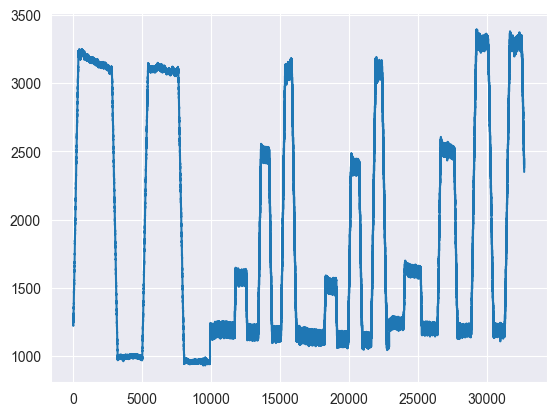

In [94]:
all_ts.plot()

In [95]:
tau_test = len(test_1_ts)
tau_val=len(test_1_ts)

train=all_ts[:-(tau_val+tau_test)].copy()
val=all_ts[-(tau_val + tau_test):-tau_test].copy()
test=all_ts[-tau_test:].copy()

print(f"Train: {len(train)}, Validation: {len(val)}, Test: {len(test)}")

Train: 13115, Validation: 9795, Test: 9795


Se realiza segmentación de los datos, se selecciona igual cantidad de datos para el conjunto de validación, que los existente en la base de datos de test.

#### SES

In [96]:
def plot_model(train, val, test, y_pred, title):
    plt.figure(figsize=(10, 6))

    train.plot(legend=True, label="Train", color='blue', title=f"{title} - Train, Validation, Test and Prediction")
    val.plot(legend=True, label="Validation", color='orange')
    test.plot(legend=True, label="Test", color='green')
    y_pred.plot(legend=True, label="Prediction", color='red', style='--')

    mae = mean_absolute_error(test, y_pred)
    plt.title(f"{title}, MAE: {round(mae, 2)}")

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.show()

In [97]:
def ses_optimizer(train, val, alphas, step_val):

    best_alpha, best_mae = None, float("inf")

    for alpha in alphas:
        ses_model = SimpleExpSmoothing(train).fit(smoothing_level=alpha, optimized=False)
        y_pred = ses_model.forecast(step_val)
        mae = mean_absolute_error(val, y_pred)

        if mae < best_mae:
            best_alpha, best_mae = alpha, mae

    return best_alpha, best_mae

In [98]:
def ses_model_tuning(train, val, test, step_test, step_val,title="Model Tuning - Single Exponential Smoothing"):
    
    alphas = np.arange(0.8, 1, 0.01)
    best_alpha, best_mae = ses_optimizer(train, val, alphas, step_val=step_val)
    
    train_val = pd.concat([train, val])
    final_model = SimpleExpSmoothing(train_val).fit(smoothing_level=best_alpha, optimized=False)
    
    y_pred = final_model.forecast(step_test)
    mae = mean_absolute_error(test, y_pred)
    
    plot_model(train, val, test, y_pred, title)

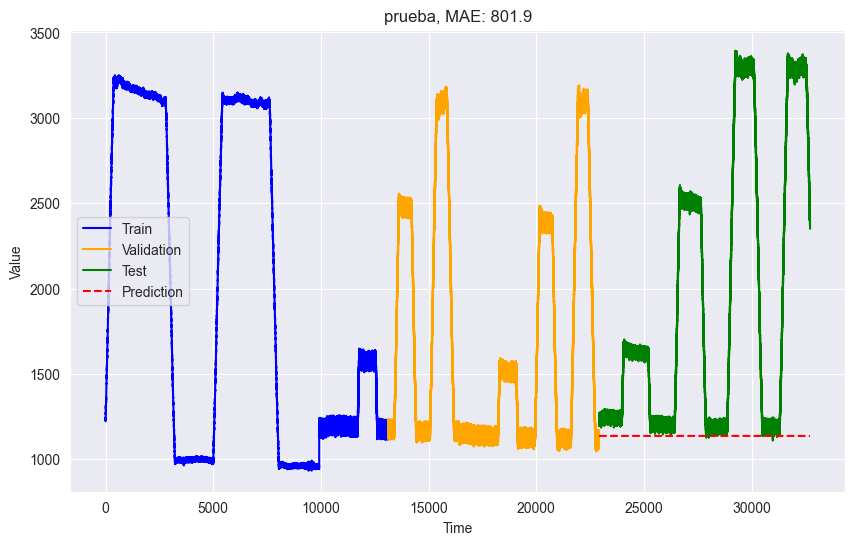

In [99]:
ses_model_tuning(train, val, test, step_test=tau_test,step_val=tau_val,title='prueba')

#### DES

In [100]:
def des_optimizer(train, val, alphas, betas, trend, step_val):

    best_alpha, best_beta, best_mae = None, None, float("inf")
    for alpha in alphas:
        for beta in betas:
            des_model = ExponentialSmoothing(train, trend=trend).fit(smoothing_level=alpha, smoothing_slope=beta)
            y_pred = des_model.forecast(step_val)
            mae = mean_absolute_error(val, y_pred)
            if mae < best_mae:
                best_alpha, best_beta, best_mae = alpha, beta, mae
    return best_alpha, best_beta, best_mae


In [101]:
def des_model_tuning(train , val, test,step_val,step_test, trend, title="Model Tuning - Double Exponential Smoothing"):
    
    alphas = np.arange(0.35,1,1)
    betas  = np.arange(0.06,1,1)
    print(alphas)
    print(betas)
    best_alpha, best_beta, best_mae = des_optimizer(train, val, alphas, betas, trend=trend, step_val=step_val)

    train_val = pd.concat([train, val])
    final_model = ExponentialSmoothing(train_val, trend=trend).fit(smoothing_level=best_alpha, smoothing_slope=best_beta)
    y_pred = final_model.forecast(step_test)
    mae = mean_absolute_error(test, y_pred)
    
    plot_model(train, val, test, y_pred, title)

[0.35]
[0.06]


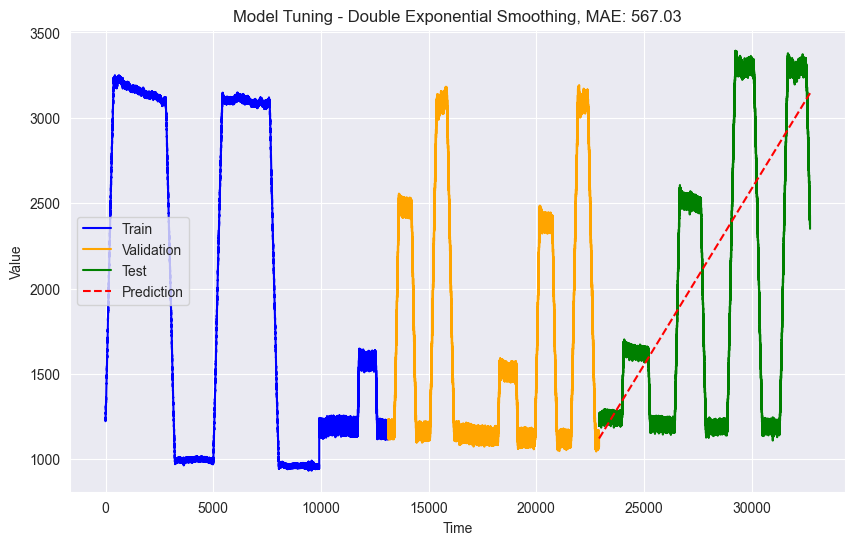

In [102]:
des_model_tuning(train, val, test, step_val=tau_val,step_test=tau_test, trend='add')

#### TES

([<matplotlib.axis.XTick at 0x1b4621146d0>,
 [Text(0, 0, '0'),
  Text(500, 0, '500'),
  Text(1000, 0, '1000'),
  Text(1500, 0, '1500'),
  Text(2000, 0, '2000'),
  Text(2500, 0, '2500'),
  Text(3000, 0, '3000'),
  Text(3500, 0, '3500'),
  Text(4000, 0, '4000'),
  Text(4500, 0, '4500'),
  Text(5000, 0, '5000'),
  Text(5500, 0, '5500'),
  Text(6000, 0, '6000'),
  Text(6500, 0, '6500'),
  Text(7000, 0, '7000'),
  Text(7500, 0, '7500'),
  Text(8000, 0, '8000')])

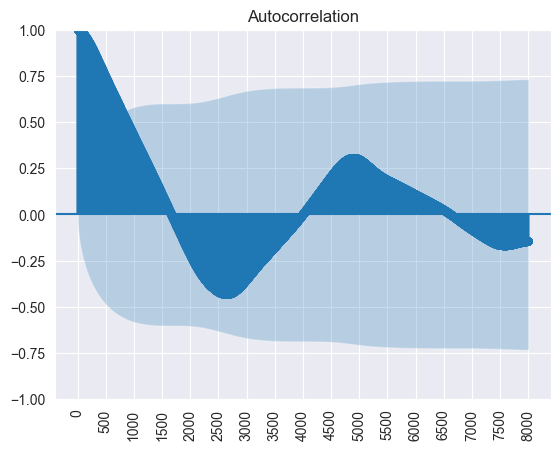

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(train,lags=8000)
plt.xticks(range(0, 8001, 500),rotation=90)

Por medio de la interpretación del gráfico de autocorrelación encontramos una posible estacionalidad, en los picos y vayes en lapsos de 2500 segundos. 

Un estimado cercano de los periodos estacionales también pude encontrarse, al sumar la cantidad de datos y dividirlo entre el número de vayes o picos visibles en las gráfica de la serie temporal. 

Por lo anteior, se define `Seasonal_periods=2550`. 

In [104]:
import pandas as pd

tau_test = len(test_1_ts)
tau_val=len(test_1_ts)

train=all_ts[:-(tau_val+tau_test)].copy()
train.index = pd.to_datetime(train.index, unit='D')
start_time = train.index.min()
end_time = train.index.max()
new_index = pd.date_range(start=start_time, end=end_time, freq='D')
train = train.reindex(new_index)

val=all_ts[-(tau_val + tau_test):-tau_test].copy()
val.index = pd.to_datetime(val.index, unit='D')
start_time = val.index.min()
end_time = val.index.max()
new_index = pd.date_range(start=start_time, end=end_time, freq='D')
val = val.reindex(new_index)

test=all_ts[-tau_test:].copy()
test.index = pd.to_datetime(test.index, unit='D')
start_time = test.index.min()
end_time = test.index.max()
new_index = pd.date_range(start=start_time, end=end_time, freq='D')
test = test.reindex(new_index)

print(f"Train: {len(train)}, Validation: {len(val)}, Test: {len(test)}")

print("Frecuencia de train:", train.index.freq)
print("Frecuencia de val:", val.index.freq)
print("Frecuencia de test:", test.index.freq)

Train: 13115, Validation: 9795, Test: 9795
Frecuencia de train: <Day>
Frecuencia de val: <Day>
Frecuencia de test: <Day>


Dado que ExponentialSmoothing() no reconoce la frecuencia de 'S' para el procesamiento de datos se realiza cambio ficticio, en el que cada fila de información pasa a representar un día y no un segundo. Este cambio sólo es un asunto de forma el cual no afecta la interpretación final de los modelos resultantes. 

In [105]:
def tes_optimizer(train, val, abg, trend, seasonal,  seasonal_periods, step_val):

    best_alpha, best_beta, best_gamma, best_mae = None, None, None, float("inf")
    for comb in abg:
        tes_model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods,freq='D').\
            fit(smoothing_level=comb[0], smoothing_slope=comb[1], smoothing_seasonal=comb[2])
        y_pred = tes_model.forecast(step_val)
        print("Longitud de y_true (val):", len(val))  # Impresión para inspección
        print("Longitud de y_pred:", len(y_pred))
        print("val:", val.head()) 
        print("y_pred:", y_pred.head())
        if len(val) == len(y_pred):
            mae = mean_absolute_error(val, y_pred)
        else:
            print("Error: Longitudes no coinciden al calcular MAE.1")
            print(f"Longitud de y_true (val): {len(val)}")
            print(f"Longitud de y_pred: {len(y_pred)}")
        mae = mean_absolute_error(val, y_pred)
        if mae < best_mae:
            best_alpha, best_beta, best_gamma, best_mae = comb[0], comb[1], comb[2], mae

    print(f"Predicciones: {y_pred}, Longitud: {len(y_pred)}")
    print(f"Validación: {val}, Longitud: {len(val)}")
    return best_alpha, best_beta, best_gamma, best_mae


In [106]:
def tes_model_tuning(train, val, test, step_val, step_test, trend, seasonal, seasonal_periods, title="Model Tuning - Triple Exponential Smoothing"):
    
    alphas = np.arange(0.35,1,1)
    betas = np.arange(0.024,1,1)
    gammas = np.arange(0.45,1,1)
    abg = list(itertools.product(alphas, betas, gammas))
    best_alpha, best_beta, best_gamma, best_mae = tes_optimizer(train, val, abg=abg, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods, step_val=step_val)
    train_val = pd.concat([train, val])
    final_model = ExponentialSmoothing(train_val, trend=trend, seasonal=seasonal,seasonal_periods=seasonal_periods,freq='D').fit(smoothing_level=best_alpha, smoothing_slope=best_beta, smoothing_seasonal=best_gamma)
    y_pred = final_model.forecast(step_test)[-step_val:]
    if len(val) == len(y_pred):
        mae = mean_absolute_error(val, y_pred)
    else:
        print("Error: Longitudes    no coinciden al calcular MAE.2")
        print(f"Longitud de y_true (val): {len(val)}")
        print(f"Longitud de y_pred: {len(y_pred)}")

    mae = mean_absolute_error(test, y_pred)
    
    plot_model(train, val, test, y_pred, title)
    
    return best_alpha, best_beta, best_gamma, best_mae

Tener un rango amplio de `alphas, betas y gamma`  eleva exponencialmente el tiempo de procesamiento. Por lo cual, dadas las limitaciones de computo, se realizaron varias iteraciones con valores fijos de `alphas, betas y gammas`. Para textear el tiempo de procesamiento cuando, se definían diferentes valores para `seasonal_periods`. A continuación un gráfico del tiempo de procesamiento recopilados manualmente: 

Longitud de y_true (val): 9795
Longitud de y_pred: 9795
val: 2005-11-28    1220.905639
2005-11-29    1127.822835
2005-11-30    1227.550653
2005-12-01    1140.003245
2005-12-02    1223.458362
Freq: D, Name: el_power, dtype: float64
y_pred: 2005-11-28    1217.896010
2005-11-29    1125.272348
2005-11-30    1214.537542
2005-12-01    1132.348392
2005-12-02    1219.706497
Freq: D, dtype: float64
Predicciones: 2005-11-28    1217.896010
2005-11-29    1125.272348
2005-11-30    1214.537542
2005-12-01    1132.348392
2005-12-02    1219.706497
                 ...     
2032-09-17    1209.864865
2032-09-18    1121.534453
2032-09-19    1212.418023
2032-09-20    1129.843579
2032-09-21    1216.695168
Freq: D, Length: 9795, dtype: float64, Longitud: 9795
Validación: 2005-11-28    1220.905639
2005-11-29    1127.822835
2005-11-30    1227.550653
2005-12-01    1140.003245
2005-12-02    1223.458362
                 ...     
2032-09-17    1161.650866
2032-09-18    1068.605864
2032-09-19    1159.211170
2032-09

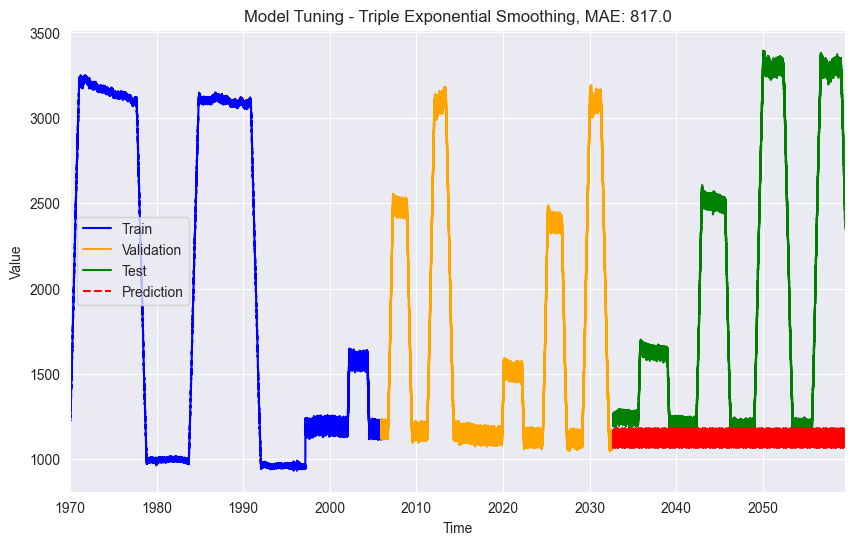

In [107]:
seasonal_periods = 100 # Ajusta este valor según tus datos
best_alpha, best_beta, best_gamma, best_mae = tes_model_tuning(
    train, val, test, 
    step_val=tau_val, 
    step_test=tau_test, 
    trend=None, 
    seasonal='add', 
    seasonal_periods=seasonal_periods
)

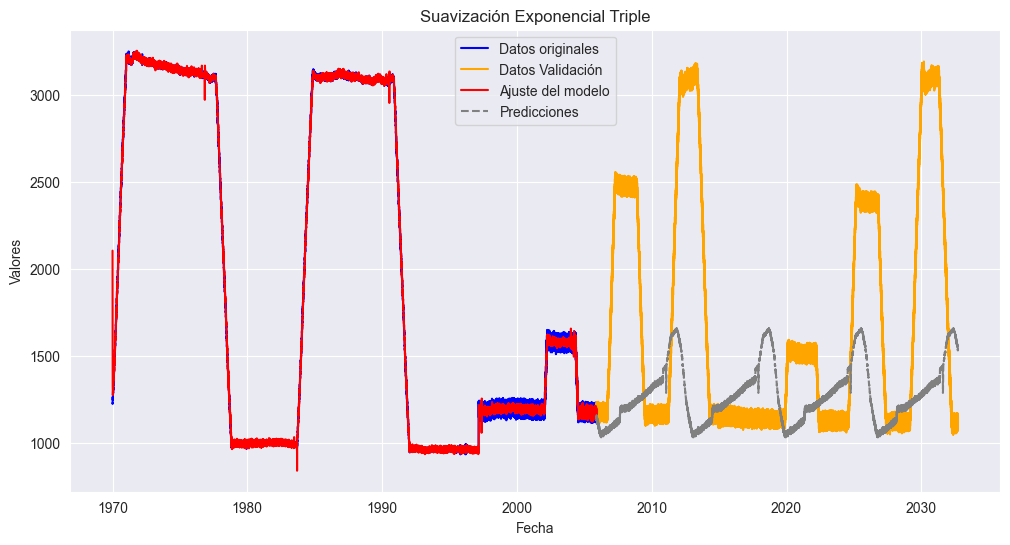

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Ajustar el modelo de suavización exponencial triple
model = ExponentialSmoothing(train, trend=None, seasonal='add', seasonal_periods=2500)
fit = model.fit()

# Realizar predicciones
pred = fit.forecast(steps=tau_val)

# Visualizar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train, label='Datos originales', color='blue')
plt.plot(val,label='Datos Validación',color='orange')
plt.plot(fit.fittedvalues, label='Ajuste del modelo', color='red')
plt.plot(pred, label='Predicciones', color='grey', linestyle='--')
plt.title('Suavización Exponencial Triple')
plt.xlabel('Fecha')
plt.ylabel('Valores')
plt.legend()
plt.show()


## Series continuas

In [109]:
train_2_ts = pd.Series(data=train_2['el_power'].values, index=train_2.index).reset_index(drop=True)
train_4_ts = pd.Series(data=train_4['el_power'].values, index=train_4.index).reset_index(drop=True)
train_6_ts = pd.Series(data=train_6['el_power'].values, index=train_6.index).reset_index(drop=True)
train_ts_cont = [train_2_ts, train_4_ts, train_6_ts]


In [110]:
import numpy as np
import pandas as pd

# Define las funciones
def firstsmooth(y, lambda_, start=None):
    ytilde = y.copy()
    if start is None:
        start = y[0]
    ytilde[0] = lambda_ * y[0] + (1 - lambda_) * start
    for i in range(1, len(y)):
        ytilde[i] = lambda_ * y[i] + (1 - lambda_) * ytilde[i - 1]
    return ytilde


In [111]:
def measacc_fs(y, lambda_):
    out = firstsmooth(y, lambda_)
    T = len(y)
    yh = y.copy().values
    out = pd.concat([pd.Series([y[0]]), out[:-1]], ignore_index=True).values
    prederr = yh - out
    SSE = sum(prederr**2)
    MAPE = 100 * sum(abs(prederr / yh)) / T
    MAD = sum(abs(prederr)) / T
    MSD = sum(prederr**2) / T
    ret1 = pd.DataFrame({
        "SSE": [SSE],
        "MAPE": [MAPE],
        "MAD": [MAD],
        "MSD": [MSD]
    })
    ret1.reset_index(drop=True, inplace=True)    
    return ret1


### Selección $\lambda$

In [112]:
lambda_vec = np.arange(0.1, 1.0, 0.05)

In [113]:
train_ts_cont[1]

0       1102.949693
1       1199.403786
2       1113.199817
3       1200.377939
4       1105.465349
           ...     
9183    1087.480971
9184    1175.438134
9185    1084.135839
9186    1159.916874
9187    1077.133288
Length: 9188, dtype: float64

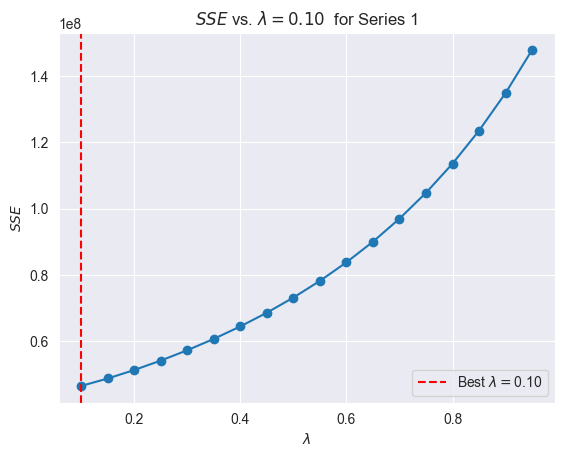

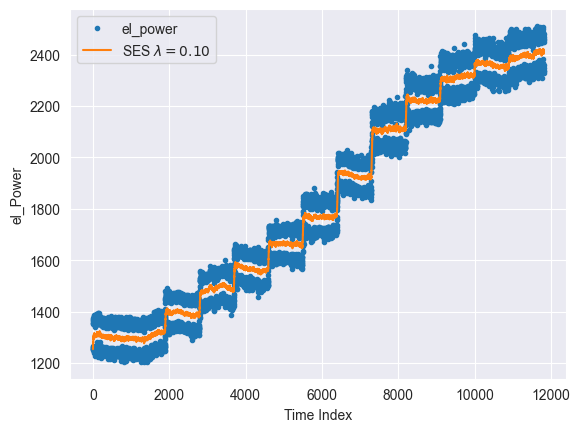

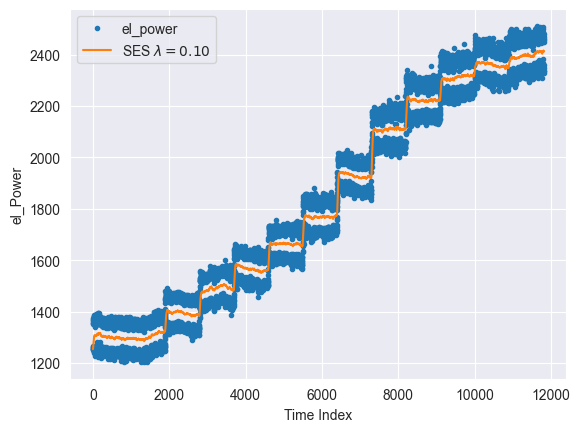

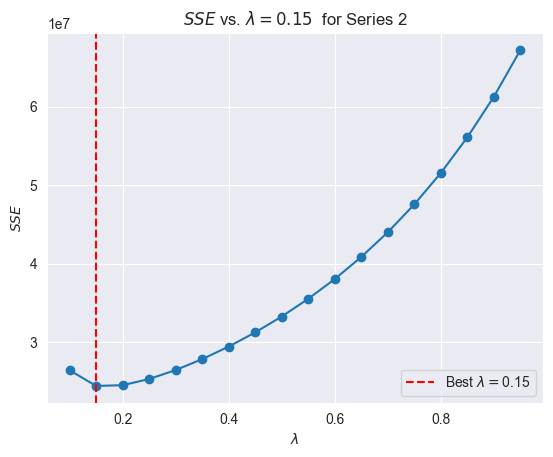

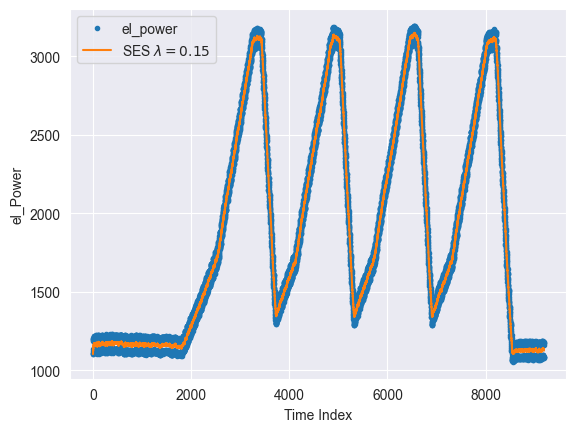

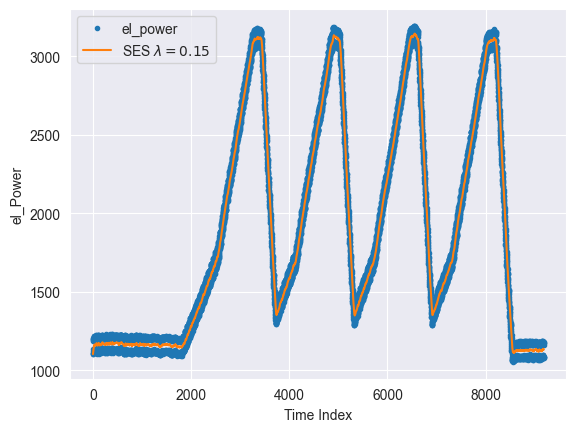

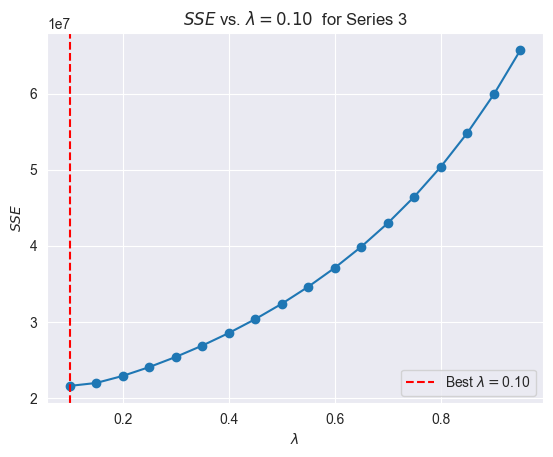

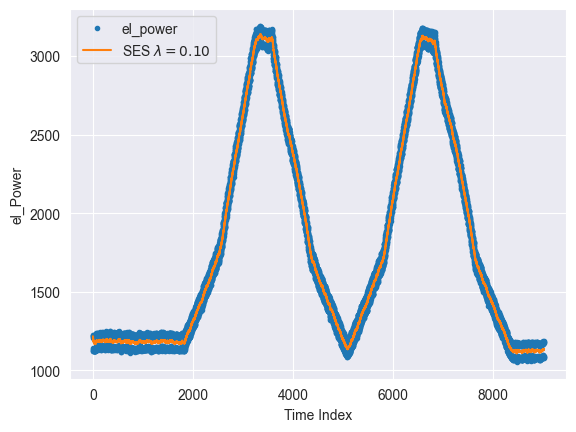

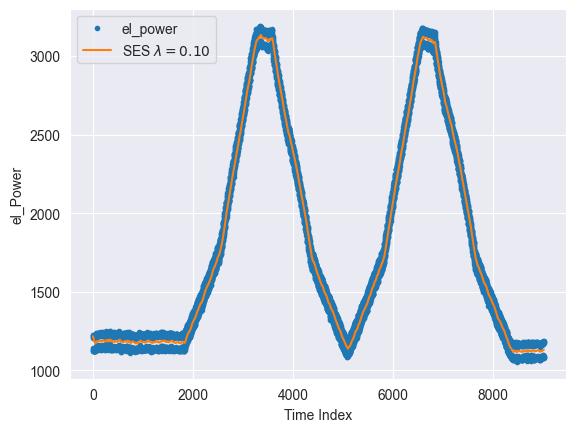

In [114]:
opt_lambda_vec=[]
for i, ts_cont in enumerate(train_ts_cont):
    # Define la función SSE
    def sse(sc):
        return measacc_fs(ts_cont, sc)['SSE'].values[0]

    # Inicializa sse_vec con el mismo tamaño que lambda_vec
    sse_vec = pd.Series(index=lambda_vec)

    # Calcula SSE para cada valor de lambda
    for lambda_ in lambda_vec:
        sse_vec.loc[lambda_] = sse(lambda_)

    # Filtra los valores NaN para evitar problemas
    sse_vec_filtered = sse_vec.dropna()

    # Asegúrate de que el mínimo existe antes de intentar graficar
    if not sse_vec_filtered.empty:
        opt_lambda = sse_vec_filtered.idxmin()
        opt_lambda_vec.append(opt_lambda)
        # Gráfico
        plt.plot(lambda_vec, sse_vec, marker='o', linestyle='-')
        plt.title(f"$SSE$ vs. $\lambda={opt_lambda:.2f}$  for Series {i+1}")
        plt.xlabel('$\lambda$')
        plt.ylabel('$SSE$')
        plt.axvline(x=opt_lambda, color='red', linestyle='--', label=f'Best $\lambda =${opt_lambda:.2f}')
        plt.legend()
        plt.show()
        
    smooth1 = firstsmooth(y=ts_cont, lambda_=opt_lambda)
    plt.plot(ts_cont, marker='o', linestyle='', markersize=3, label='el_power')
    plt.plot(smooth1, label=f'SES $\\lambda={opt_lambda:.2f}$')
    plt.xlabel('Time Index')
    plt.ylabel('el_Power')
    plt.legend()
    plt.show()
    
    smooth2 = firstsmooth(y=smooth1, lambda_=opt_lambda)
    plt.plot(ts_cont, marker='o', linestyle='', markersize=3, label='el_power')
    plt.plot(smooth2, label=f'SES $\\lambda={opt_lambda:.2f}$')
    plt.xlabel('Time Index')
    plt.ylabel('el_Power')
    plt.legend()
    plt.show()

In [115]:
opt_lambda_vec

[0.1, 0.15000000000000002, 0.1]

In [116]:
results = []
# Itera sobre los datos
for i, ts_cont in enumerate(train_ts_cont):
    for j, lambda_ in enumerate(opt_lambda_vec):
        # Calcula la métrica
        metrics = measacc_fs(y=ts_cont, lambda_=lambda_)
        
        # Guarda los resultados en la lista
        results.append({
            'Train': 2*i+1,
            'Lambda': lambda_,
            'SSE': metrics['SSE'].values[0],
            'MAPE': metrics['MAPE'].values[0],
            'MAD': metrics['MAD'].values[0],
            'MSD': metrics['MSD'].values[0]
        })

# Convierte la lista a un DataFrame
mx_result = pd.DataFrame(results)

# Muestra el DataFrame final
print(mx_result)

            

   Train  Lambda           SSE      MAPE        MAD          MSD
0      1    0.10  4.648336e+07  3.490945  61.153435  3932.934818
1      1    0.15  4.872328e+07  3.584319  62.775446  4122.453424
2      1    0.10  4.648336e+07  3.490945  61.153435  3932.934818
3      3    0.10  2.643325e+07  2.897667  48.826658  2876.932039
4      3    0.15  2.443745e+07  2.896752  48.481375  2659.713215
5      3    0.10  2.643325e+07  2.897667  48.826658  2876.932039
6      5    0.10  2.157865e+07  2.950116  47.026061  2391.516498
7      5    0.15  2.196497e+07  3.029629  48.296951  2434.331183
8      5    0.10  2.157865e+07  2.950116  47.026061  2391.516498


Al realizar el comparativo de los valores del `MAPE` para combinación de los conjuntos de entrenamientos y $\lambda$ optimos por modelo. Se obtiene que el valor de $\lambda$ que minimiza el porcentaje de error de las predicciones en relación al valor real (MAPE)es:


In [117]:
idx_min_mape = mx_result['MAPE'].idxmin()
optimal_lambda = mx_result.loc[idx_min_mape, 'Lambda']
optimal_lambda

0.15000000000000002

### Ajuste con todos los datos de entrenamiento

Se unifican datos, para realizar las predicciones. Se utilizará la métrica de `MAE`para evaluar el mejor ajuste del modelo de suavización exponencial, simple, doble y triple.

In [118]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.api as smt

train_2_ts = pd.Series(data=train_2['el_power'].values, index=train_2.index)
train_4_ts = pd.Series(data=train_4['el_power'].values, index=train_4.index)
train_6_ts = pd.Series(data=train_6['el_power'].values, index=train_6.index)
test_2_ts = pd.Series(data=test_2['el_power'].values, index=test_2.index)
all_ts_2 = pd.concat([train_2_ts, train_4_ts,train_6_ts,test_2_ts], axis=0,ignore_index=True)
lambda_ = optimal_lambda
all_ts_2.name = 'el_power'
all_ts_2.head()


0    1253.790314
1    1349.836854
2    1262.033813
3    1370.205819
4    1254.782490
Name: el_power, dtype: float64

In [119]:
all_ts_2.isnull().sum()

0

<Axes: >

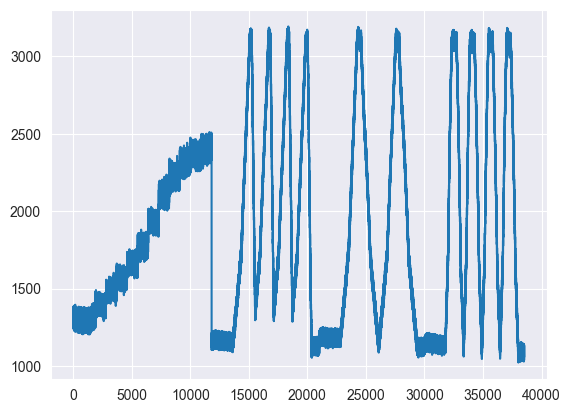

In [120]:
all_ts_2.plot()

In [121]:
tau_test = len(test_2_ts)
tau_val=len(test_2_ts)

train=all_ts_2[:-(tau_val+tau_test)].copy()
val=all_ts_2[-(tau_val + tau_test):-tau_test].copy()
test=all_ts_2[-tau_test:].copy()

print(f"Train: {len(train)}, Validation: {len(val)}, Test: {len(test)}")

Train: 21540, Validation: 8490, Test: 8490


Se realiza segmentación de los datos, se selecciona igual cantidad de datos para el conjunto de validación, que los existente en la base de datos de test.

#### SES

In [122]:
def plot_model(train, val, test, y_pred, title):
    plt.figure(figsize=(10, 6))

    train.plot(legend=True, label="Train", color='blue', title=f"{title} - Train, Validation, Test and Prediction")
    val.plot(legend=True, label="Validation", color='orange')
    test.plot(legend=True, label="Test", color='green')
    y_pred.plot(legend=True, label="Prediction", color='red', style='--')

    mae = mean_absolute_error(test, y_pred)
    plt.title(f"{title}, MAE: {round(mae, 2)}")

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.show()

In [123]:
def ses_optimizer(train, val, alphas, step_val):

    best_alpha, best_mae = None, float("inf")

    for alpha in alphas:
        ses_model = SimpleExpSmoothing(train).fit(smoothing_level=alpha, optimized=False)
        y_pred = ses_model.forecast(step_val)
        mae = mean_absolute_error(val, y_pred)

        if mae < best_mae:
            best_alpha, best_mae = alpha, mae

    return best_alpha, best_mae

In [124]:
def ses_model_tuning(train, val, test, step_test, step_val,title="Model Tuning - Single Exponential Smoothing"):
    
    alphas = np.arange(0.8, 1, 0.01)
    best_alpha, best_mae = ses_optimizer(train, val, alphas, step_val=step_val)
    
    train_val = pd.concat([train, val])
    final_model = SimpleExpSmoothing(train_val).fit(smoothing_level=best_alpha, optimized=False)
    
    y_pred = final_model.forecast(step_test)
    mae = mean_absolute_error(test, y_pred)
    
    plot_model(train, val, test, y_pred, title)

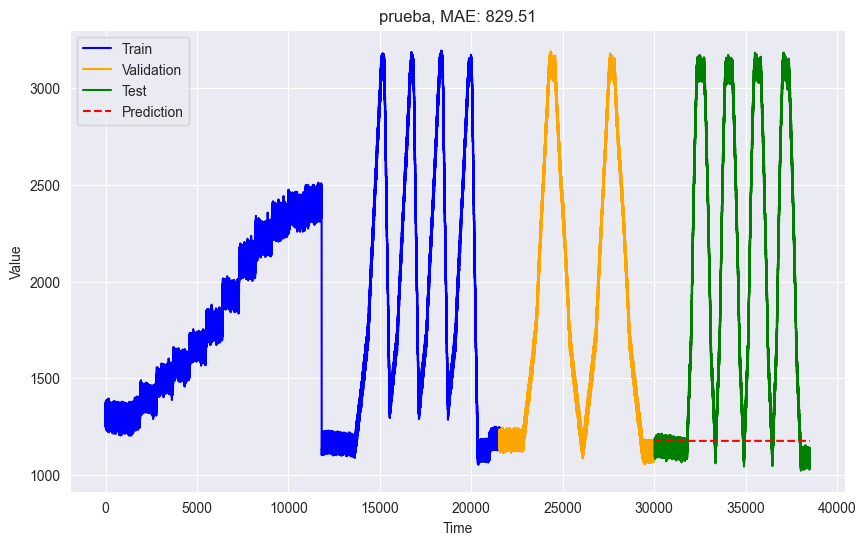

In [125]:
ses_model_tuning(train, val, test, step_test=tau_test,step_val=tau_val,title='prueba')

#### DES

In [126]:
def des_optimizer(train, val, alphas, betas, trend, step_val):

    best_alpha, best_beta, best_mae = None, None, float("inf")
    for alpha in alphas:
        for beta in betas:
            des_model = ExponentialSmoothing(train, trend=trend).fit(smoothing_level=alpha, smoothing_slope=beta)
            y_pred = des_model.forecast(step_val)
            mae = mean_absolute_error(val, y_pred)
            if mae < best_mae:
                best_alpha, best_beta, best_mae = alpha, beta, mae
    return best_alpha, best_beta, best_mae


In [127]:
def des_model_tuning(train , val, test,step_val,step_test, trend, title="Model Tuning - Double Exponential Smoothing"):
    
    alphas = np.arange(0.15,1,1)
    betas  = np.arange(0.07,1,1)
    print(alphas)
    print(betas)
    best_alpha, best_beta, best_mae = des_optimizer(train, val, alphas, betas, trend=trend, step_val=step_val)

    train_val = pd.concat([train, val])
    final_model = ExponentialSmoothing(train_val, trend=trend).fit(smoothing_level=best_alpha, smoothing_slope=best_beta)
    y_pred = final_model.forecast(step_test)
    mae = mean_absolute_error(test, y_pred)
    
    plot_model(train, val, test, y_pred, title)

[0.15]
[0.07]


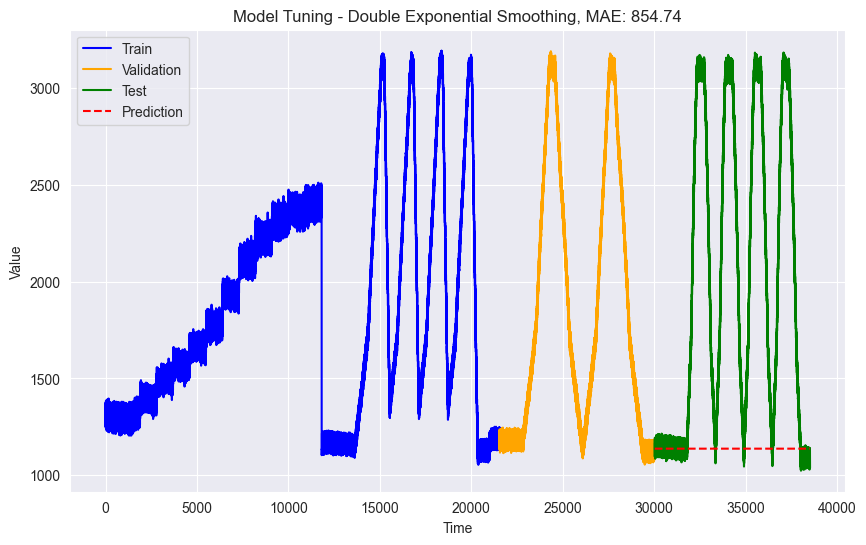

In [128]:
des_model_tuning(train, val, test, step_val=tau_val,step_test=tau_test, trend=None)

#### TES

([<matplotlib.axis.XTick at 0x1b46968fe80>,
 [Text(0, 0, '0'),
  Text(500, 0, '500'),
  Text(1000, 0, '1000'),
  Text(1500, 0, '1500'),
  Text(2000, 0, '2000'),
  Text(2500, 0, '2500'),
  Text(3000, 0, '3000'),
  Text(3500, 0, '3500'),
  Text(4000, 0, '4000'),
  Text(4500, 0, '4500'),
  Text(5000, 0, '5000'),
  Text(5500, 0, '5500'),
  Text(6000, 0, '6000'),
  Text(6500, 0, '6500'),
  Text(7000, 0, '7000'),
  Text(7500, 0, '7500'),
  Text(8000, 0, '8000')])

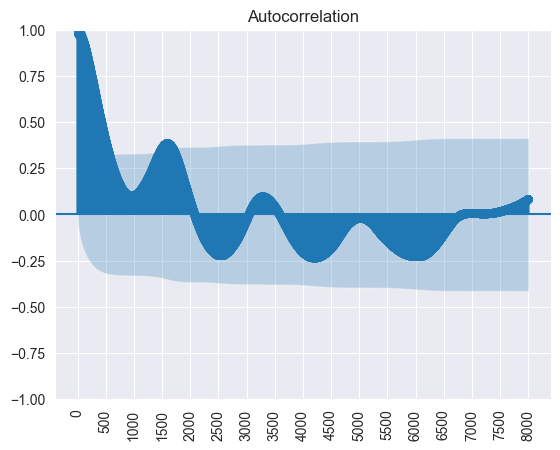

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(train,lags=8000)
plt.xticks(range(0, 8001, 500),rotation=90)

Por medio de la interpretación del gráfico de autocorrelación encontramos una posible estacionalidad, en los picos y vayes en lapsos de 1500 segundos. 

Un estimado cercano de los periodos estacionales también pude encontrarse, al sumar la cantidad de datos y dividirlo entre el número de vayes o picos visibles en las gráfica de la serie temporal. 

Por lo anteior, se define `Seasonal_periods=1200`. 

In [130]:
import pandas as pd

tau_test = len(test_1_ts)
tau_val=len(test_1_ts)

train=all_ts_2[:-(tau_val+tau_test)].copy()
train.index = pd.to_datetime(train.index, unit='D')
start_time = train.index.min()
end_time = train.index.max()
new_index = pd.date_range(start=start_time, end=end_time, freq='D')
train = train.reindex(new_index)

val=all_ts_2[-(tau_val + tau_test):-tau_test].copy()
val.index = pd.to_datetime(val.index, unit='D')
start_time = val.index.min()
end_time = val.index.max()
new_index = pd.date_range(start=start_time, end=end_time, freq='D')
val = val.reindex(new_index)

test=all_ts_2[-tau_test:].copy()
test.index = pd.to_datetime(test.index, unit='D')
start_time = test.index.min()
end_time = test.index.max()
new_index = pd.date_range(start=start_time, end=end_time, freq='D')
test = test.reindex(new_index)

print(f"Train: {len(train)}, Validation: {len(val)}, Test: {len(test)}")

print("Frecuencia de train:", train.index.freq)
print("Frecuencia de val:", val.index.freq)
print("Frecuencia de test:", test.index.freq)

Train: 18930, Validation: 9795, Test: 9795
Frecuencia de train: <Day>
Frecuencia de val: <Day>
Frecuencia de test: <Day>


Dado que ExponentialSmoothing() no reconoce la frecuencia de 'S' para el procesamiento de datos se realiza cambio ficticio, en el que cada fila de información pasa a representar un día y no un segundo. Este cambio sólo es un asunto de forma el cual no afecta la interpretación final de los modelos resultantes. 

In [131]:
def tes_optimizer(train, val, abg, trend, seasonal,  seasonal_periods, step_val):

    best_alpha, best_beta, best_gamma, best_mae = None, None, None, float("inf")
    for comb in abg:
        tes_model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods,freq='D').\
            fit(smoothing_level=comb[0], smoothing_slope=comb[1], smoothing_seasonal=comb[2])
        y_pred = tes_model.forecast(step_val)
        print("Longitud de y_true (val):", len(val))  # Impresión para inspección
        print("Longitud de y_pred:", len(y_pred))
        print("val:", val.head()) 
        print("y_pred:", y_pred.head())
        if len(val) == len(y_pred):
            mae = mean_absolute_error(val, y_pred)
        else:
            print("Error: Longitudes no coinciden al calcular MAE.1")
            print(f"Longitud de y_true (val): {len(val)}")
            print(f"Longitud de y_pred: {len(y_pred)}")
        mae = mean_absolute_error(val, y_pred)
        if mae < best_mae:
            best_alpha, best_beta, best_gamma, best_mae = comb[0], comb[1], comb[2], mae

    print(f"Predicciones: {y_pred}, Longitud: {len(y_pred)}")
    print(f"Validación: {val}, Longitud: {len(val)}")
    return best_alpha, best_beta, best_gamma, best_mae


In [132]:
def tes_model_tuning(train, val, test, step_val, step_test, trend, seasonal, seasonal_periods, title="Model Tuning - Triple Exponential Smoothing"):
    
    alphas = np.arange(0.15,1,1)
    betas = np.arange(0.025,1,1)
    gammas = np.arange(0.45,1,1)
    abg = list(itertools.product(alphas, betas, gammas))
    best_alpha, best_beta, best_gamma, best_mae = tes_optimizer(train, val, abg=abg, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods, step_val=step_val)
    train_val = pd.concat([train, val])
    final_model = ExponentialSmoothing(train_val, trend=trend, seasonal=seasonal,seasonal_periods=seasonal_periods,freq='D').fit(smoothing_level=best_alpha, smoothing_slope=best_beta, smoothing_seasonal=best_gamma)
    y_pred = final_model.forecast(step_test)[-step_val:]
    if len(val) == len(y_pred):
        mae = mean_absolute_error(val, y_pred)
    else:
        print("Error: Longitudes    no coinciden al calcular MAE.2")
        print(f"Longitud de y_true (val): {len(val)}")
        print(f"Longitud de y_pred: {len(y_pred)}")

    mae = mean_absolute_error(test, y_pred)
    
    plot_model(train, val, test, y_pred, title)
    
    return best_alpha, best_beta, best_gamma, best_mae

Tener un rango amplio de `alphas, betas y gamma`  eleva exponencialmente el tiempo de procesamiento. Por lo cual, dadas las limitaciones de computo, se realizaron varias iteraciones con valores fijos de `alphas, betas y gammas`. Para textear el tiempo de procesamiento cuando, se definían diferentes valores para `seasonal_periods`. A continuación un gráfico del tiempo de procesamiento recopilados manualmente: 

Longitud de y_true (val): 9795
Longitud de y_pred: 9795
val: 2021-10-30    1483.034276
2021-10-31    1573.326660
2021-11-01    1489.743518
2021-11-02    1580.631205
2021-11-03    1494.476241
Freq: D, Name: el_power, dtype: float64
y_pred: 2021-10-30    1502.906212
2021-10-31    1547.828785
2021-11-01    1505.482858
2021-11-02    1554.522497
2021-11-03    1505.648312
Freq: D, dtype: float64
Predicciones: 2021-10-30    1502.906212
2021-10-31    1547.828785
2021-11-01    1505.482858
2021-11-02    1554.522497
2021-11-03    1505.648312
                 ...     
2048-08-19    1378.875615
2048-08-20    1451.068063
2048-08-21    1383.004713
2048-08-22    1449.148486
2048-08-23    1390.201398
Freq: D, Length: 9795, dtype: float64, Longitud: 9795
Validación: 2021-10-30    1483.034276
2021-10-31    1573.326660
2021-11-01    1489.743518
2021-11-02    1580.631205
2021-11-03    1494.476241
                 ...     
2048-08-19    1604.262647
2048-08-20    1690.161066
2048-08-21    1594.856867
2048-08

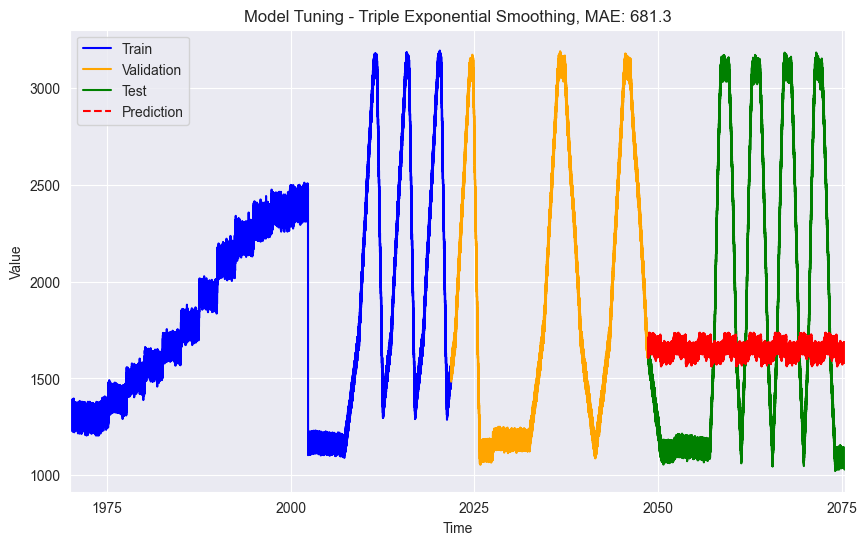

In [133]:
seasonal_periods = 1250
best_alpha, best_beta, best_gamma, best_mae = tes_model_tuning(
    train, val, test, 
    step_val=tau_val, 
    step_test=tau_test, 
    trend=None, 
    seasonal='add', 
    seasonal_periods=seasonal_periods
)

## Conclusiones

Los modelos de suavización exponencial permiten replicar patrones estacionales significativos. Esto se evidenció tanto en los modelos ajustados SES, DES y TES. Sin embargo el costo computacional es significativamente alto. Dado que la busqueda de los factores optimos se realiza de manera iterada, en la medida que aumentan la cantidades de datos aumenta la complejidad computacional. 

Por lo tanto, como resultado tenemos dos modelos de suavización exponencial, uno para tipo de series rectangulares y conitnuas. Con resultados de MAE 925.84 y 681.3, respectivamente. 

Las gráficas de los valores de las predicciones, evidencian una significativa falta de ajueste de los parámetros `alpha, betas y gammas` que garanticen una mejor predicción.

Sin embargo, con la limitación de recursos computacionales existence, los resultados obtenidos son los mejores encontrados haciendo iteraciones una a una, a prueba y error.